# Strategy analysis example

Debugging a strategy can be time-consuming. Freqtrade offers helper functions to visualize raw data.
The following assumes you work with SampleStrategy, data for 5m timeframe from Binance and have downloaded them into the data directory in the default location.
Please follow the [documentation](https://www.freqtrade.io/en/stable/data-download/) for more details.

## Setup

### Change Working directory to repository root

In [1]:
import os
from pathlib import Path


# Change directory
# Modify this cell to insure that the output shows the correct path.
# Define all paths relative to the project root shown in the cell output
project_root = "/Users/conradlz/Documents/webclones/freqtrade"
i = 0
try:
    os.chdir(project_root)
    if not Path("LICENSE").is_file():
        i = 0
        while i < 4 and (not Path("LICENSE").is_file()):
            os.chdir(Path(Path.cwd(), "../"))
            i += 1
        project_root = Path.cwd()
except FileNotFoundError:
    print("Please define the project root relative to the current directory")
print(Path.cwd())

/Users/conradlz/Documents/webclones/freqtrade


### Configure Freqtrade environment

In [2]:
from freqtrade.configuration import Configuration


# Customize these according to your needs.

# Initialize empty configuration object
# config = Configuration.from_files([])
# Optionally (recommended), use existing configuration file
config = Configuration.from_files(["user_data/config.json"])

# Define some constants
config["timeframe"] = "5m"
# Name of the strategy class
config["strategy"] = "WarriorMomentum"
# Location of the data
data_location = config["datadir"]
# Pair to analyze - Only use one pair here
pair = "XMR/USDT"

2025-07-20 10:48:15,609 - freqtrade.loggers - INFO - Enabling colorized output.

2025-07-20 10:48:15,612 - freqtrade.loggers - INFO - Logfile configured

2025-07-20 10:48:15,613 - freqtrade.loggers - INFO - Verbosity set to 0

2025-07-20 10:48:15,614 - freqtrade.configuration.configuration - INFO - Using user-data directory: /Users/conradlz/Documents/webclones/freqtrade/user_data ...

2025-07-20 10:48:15,615 - freqtrade.configuration.configuration - INFO - Using data directory: /Users/conradlz/Documents/webclones/freqtrade/user_data/data/kraken ...

2025-07-20 10:48:15,821 - freqtrade.exchange.check_exchange - INFO - Checking exchange...

2025-07-20 10:48:15,825 - freqtrade.exchange.check_exchange - INFO - Exchange "kraken" is officially supported by the Freqtrade development team.

In [3]:
# Load data using values set above
from freqtrade.data.history import load_pair_history


candles = load_pair_history(
    datadir=data_location,
    timeframe=config["timeframe"],
    pair=pair,
    data_format="feather",  # Make sure to update this to your data
)

# Confirm success
print(f"Loaded {len(candles)} rows of data for {pair} from {data_location}")
candles.head()

2025-07-20 10:48:16,150 - freqtrade.data.converter.converter - INFO - Missing data fillup for XMR/USDT, 5m: before: 5795 - after: 8903 - 53.63%

Loaded 8903 rows of data for XMR/USDT from /Users/conradlz/Documents/webclones/freqtrade/user_data/data/kraken


,date,open,high,low,close,volume
0,2025-06-16 21:25:00+00:00,328.75,328.75,328.74,328.74,1.022868
1,2025-06-16 21:30:00+00:00,327.16,327.16,327.14,327.14,7.000000
2,2025-06-16 21:35:00+00:00,328.59,328.67,327.82,327.82,1.524258
3,2025-06-16 21:40:00+00:00,328.08,328.09,328.08,328.09,2.732000
4,2025-06-16 21:45:00+00:00,328.09,328.09,328.09,328.09,0.000000


## Load and run strategy
* Rerun each time the strategy file is changed

In [4]:
# Load strategy using values set above
# from freqtrade.data.dataprovider import DataProvider
# from freqtrade.resolvers import StrategyResolver


# strategy = StrategyResolver.load_strategy(config)
# strategy.dp = DataProvider(config, None, None)
# strategy.ft_bot_start()

# # Generate buy/sell signals using strategy
# df = strategy.analyze_ticker(candles, {"pair": pair})
# df.tail()

### Display the trade details

* Note that using `data.head()` would also work, however most indicators have some "startup" data at the top of the dataframe.
* Some possible problems
    * Columns with NaN values at the end of the dataframe
    * Columns used in `crossed*()` functions with completely different units
* Comparison with full backtest
    * having 200 buy signals as output for one pair from `analyze_ticker()` does not necessarily mean that 200 trades will be made during backtesting.
    * Assuming you use only one condition such as, `df['rsi'] < 30` as buy condition, this will generate multiple "buy" signals for each pair in sequence (until rsi returns > 29). The bot will only buy on the first of these signals (and also only if a trade-slot ("max_open_trades") is still available), or on one of the middle signals, as soon as a "slot" becomes available.  


In [5]:
# # Report results
# print(f"Generated {df['enter_long'].sum()} entry signals")
# data = df.set_index("date", drop=False)
# data.tail()

In [6]:
from freqtrade.enums import RunMode
from freqtrade.optimize.backtesting import Backtesting
from freqtrade.resolvers import ExchangeResolver


# Configure backtest settings
config_backtest = config.copy()
config_backtest.update({
    "timerange": "",  # Use all available data
    "stake_currency": "USDT",
    "dry_run": True,
    "dataformat_ohlcv": "feather",
    "runmode": RunMode.BACKTEST,
    "pairlists": [{"method": "StaticPairList", "pairlist": [pair]}],

})

print("Setting up backtest environment...")
print(f"Strategy: {config_backtest['strategy']}")
print(f"Timeframe: {config_backtest['timeframe']}")
print(f"Pair: {pair}")
print(f"Data directory: {config_backtest['datadir']}")
print(f"Max open trades: {config_backtest['max_open_trades']}")
print(f"Stake amount: {config_backtest['stake_amount']} {config_backtest['stake_currency']}")


Setting up backtest environment...
Strategy: WarriorMomentum
Timeframe: 5m
Pair: XMR/USDT
Data directory: /Users/conradlz/Documents/webclones/freqtrade/user_data/data/kraken
Max open trades: 5
Stake amount: unlimited USDT


In [7]:
# Initialize exchange and backtesting engine
import asyncio
import nest_asyncio
from datetime import datetime

# Enable nested event loops for Jupyter notebooks
nest_asyncio.apply()

exchange = ExchangeResolver.load_exchange(config_backtest, validate=False)

# Initialize backtesting
backtesting = Backtesting(config_backtest, exchange)

print("Running backtest...")
print(f"Strategy: {config_backtest['strategy']}")
print(f"Timeframe: {config_backtest['timeframe']}")
print(f"Pair: {pair}")

# Run the full backtest process
backtesting.start()

print("Backtest completed!")
print(f"Results available in backtesting.results")





2025-07-20 10:48:16,210 - freqtrade.exchange.exchange - INFO - Instance is running with dry_run enabled

2025-07-20 10:48:16,212 - freqtrade.exchange.exchange - INFO - Using CCXT 4.4.94

2025-07-20 10:48:16,224 - freqtrade.exchange.exchange - INFO - Using Exchange "Kraken"

2025-07-20 10:48:16,226 - freqtrade.resolvers.exchange_resolver - INFO - Using resolved exchange 'Kraken'...

2025-07-20 10:48:16,360 - freqtrade.resolvers.iresolver - INFO - Using resolved strategy WarriorMomentum from '/Users/conradlz/Documents/webclones/freqtrade/user_data/strategies/WarriorMomentum.py'...

...

                                                           MIXED TAG STATS                                                            
┏━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Enter Tag ┃        Exit Reason ┃ Trades ┃ Avg Profit % ┃ Tot Profit USDT ┃ Tot Profit % ┃    Avg Duration ┃  Win  Draw  Loss  Win% ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│           │ trailing_stop_loss │     13 │         3.31 │        4396.452 │         8.79 │ 2 days, 3:11:00 │   13     0     0   100 │
│           │         force_exit │      1 │         1.25 │         131.958 │         0.26 │        12:45:00 │    1     0     0   100 │
│           │          stop_loss │      1 │       -10.71 │       -1141.258 │        -2.28 │        23:15:00 │    0     0     1     0 │
│     TOTAL │                    │     15 │         2.24 │        3387.152 │         6.77 │ 1 day, 22:45:00 │   14     0     1  93.3 │
└───────────┴────────────────────┴────────┴──────────────┴─────────────────┴──────────────┴─────────────────┴────────────────────────┘

                          SUMMARY METRICS                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Metric                        ┃ Value                           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Backtesting from              │ 2025-06-17 13:40:00             │
│ Backtesting to                │ 2025-07-17 19:15:00             │
│ Trading Mode                  │ Spot                            │
│ Max open trades               │ 5                               │
│                               │                                 │
│ Total/Daily Avg Trades        │ 15 / 0.5                        │
│ Starting balance              │ 50000 USDT                      │
│ Final balance                 │ 53387.152 USDT                  │
│ Absolute profit               │ 3387.152 USDT                   │
│ Total profit %                │ 6.77%                           │
│ CAGR %                        │ 122.00%                         │
│ Sortino                       │ -100.00                         │
│ Sharpe                        │ 4.77                            │
│ Calmar                        │ 203.32                          │
│ SQN                           │ 1.87                            │
│ Profit factor                 │ 3.97                            │
│ Expectancy (Ratio)            │ 225.81 (0.20)                   │
│ Avg. daily profit %           │ 0.23%                           │
│ Avg. stake amount             │ 10289.934 USDT                  │
│ Total trade volume            │ 314591.885 USDT                 │
│                               │                                 │
│ Best Pair                     │ XRP/USDT 3.17%                  │
│ Worst Pair                    │ ALGO/USDT -1.26%                │
│ Best trade                    │ LINK/USDT 10.78%                │
│ Worst trade                   │ ALGO/USDT -10.71%               │
│ Best day                      │ 2455.466 USDT                   │
│ Worst day                     │ -1141.258 USDT                  │
│ Days win/draw/lose            │ 8 / 9 / 1                       │
│ Min/Max/Avg. Duration Winners │ 0d 00:45 / 10d 04:25 / 2d 00:26 │
│ Min/Max/Avg. Duration Losers  │ 0d 23:15 / 0d 23:15 / 0d 23:15  │
│ Max Consecutive Wins / Loss   │ 10 / 1                          │
│ Rejected Entry signals        │ 0                               │
│ Entry/Exit Timeouts           │ 0 / 0                           │
│                               │                                 │
│ Min balance                   │ 50246.36 USDT                   │
│ Max balance                   │ 53787.548 USDT                  │
│ Max % of account underwater   │ 2.12%                           │
│ Absolute Drawdown (Account)   │ 2.12%                           │
│ Absolute Drawdown             │ 1141.258 USDT                   │
│ Drawdown high                 │ 3787.548 USDT                   │
│ Drawdown low                  │ 2646.29 USDT                    │
│ Drawdown Start                │ 2025-07-14 10:05:00             │
│ Drawdown End                  │ 2025-07-15 03:20:00             │
│ Market change                 │ 29.50%                          │
└───────────────────────────────┴─────────────────────────────────┘


Backtested 2025-06-17 13:40:00 -> 2025-07-17 19:15:00 | Max open trades : 5


                                                               STRATEGY SUMMARY                                                               
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃        Strategy ┃ Trades ┃ Avg Profit % ┃ Tot Profit USDT ┃ Tot Profit % ┃    Avg Duration ┃  Win  Draw  Loss  Win% ┃             Drawdown ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ WarriorMomentum │     15 │         2.24 │        3387.152 │         6.77 │ 1 day, 22:45:00 │   14     0     1  93.3 │ 1141.258 USDT  2.12% │
└─────────────────┴────────┴──────────────┴─────────────────┴──────────────┴─────────────────┴────────────────────────┴──────────────────────┘

Backtest completed!
Results available in backtesting.results


## Load existing objects into a Jupyter notebook

The following cells assume that you have already generated data using the cli.  
They will allow you to drill deeper into your results, and perform analysis which otherwise would make the output very difficult to digest due to information overload.

### Load backtest results to pandas dataframe

Analyze a trades dataframe (also used below for plotting)

In [8]:
from freqtrade.data.btanalysis import load_backtest_data, load_backtest_stats


# if backtest_dir points to a directory, it'll automatically load the last backtest file.
backtest_dir = config["user_data_dir"] / "backtest_results"
# backtest_dir can also point to a specific file
# backtest_dir = (
#   config["user_data_dir"] / "backtest_results/backtest-result-2020-07-01_20-04-22.json"
# )

In [10]:
# You can get the full backtest statistics by using the following command.
# This contains all information used to generate the backtest result.
stats = load_backtest_stats(backtest_dir)

strategy = "WarriorMomentum"
# All statistics are available per strategy, so if `--strategy-list` was used during backtest,
# this will be reflected here as well.
# Example usages:
print(stats["strategy"][strategy]["results_per_pair"])
# Get pairlist used for this backtest
print(stats["strategy"][strategy]["pairlist"])
# Get market change (average change of all pairs from start to end of the backtest period)
print(stats["strategy"][strategy]["market_change"])
# Maximum drawdown ()
print(stats["strategy"][strategy]["max_drawdown_abs"])
# Maximum drawdown start and end
print(stats["strategy"][strategy]["drawdown_start"])
print(stats["strategy"][strategy]["drawdown_end"])


# Get strategy comparison (only relevant if multiple strategies were compared)
print(stats["strategy_comparison"])

2025-07-20 10:49:28,181 - freqtrade.data.btanalysis.bt_fileutils - INFO - Loading backtest result from 
/Users/conradlz/Documents/webclones/freqtrade/user_data/backtest_results/backtest-result-2025-07-20_10-48-22.zip

[{'key': 'XRP/USDT', 'trades': 3, 'profit_mean': 0.051518229856423826, 'profit_mean_pct': 5.15, 'profit_sum': 0.1545546895692715, 'profit_sum_pct': 15.46, 'profit_total_abs': 1583.7353031, 'profit_total': 0.031674706062, 'profit_total_pct': 3.17, 'duration_avg': '3 days, 16:38:00', 'wins': 3, 'draws': 0, 'losses': 0, 'winrate': 1.0, 'cagr': 0.4614047867333429, 'expectancy': 527.9117677, 'expectancy_ratio': 100.0, 'sortino': -100, 'sharpe': 4.334147523147584, 'calmar': -100, 'sqn': 3.2083, 'profit_factor': 0.0, 'max_drawdown_account': 0.0, 'max_drawdown_abs': 0.0}, {'key': 'LINK/USDT', 'trades': 3, 'profit_mean': 0.048358701681666776, 'profit_mean_pct': 4.84, 'profit_sum': 0.14507610504500032, 'profit_sum_pct': 14.51, 'profit_total_abs': 1458.00355215, 'profit_total': 0.029160071043, 'profit_total_pct': 2.92, 'duration_avg': '3 days, 4:13:00', 'wins': 3, 'draws': 0, 'losses': 0, 'winrate': 1.0, 'cagr': 0.4186511921289311, 'expectancy': 486.00118405000006, 'expectancy_ratio': 100.0, 'sor

In [11]:
# Load backtested trades as dataframe
trades = load_backtest_data(backtest_dir)

# Show value-counts per pair
trades.groupby("pair")["exit_reason"].value_counts()

2025-07-20 10:49:42,751 - freqtrade.data.btanalysis.bt_fileutils - INFO - Loading backtest result from 
/Users/conradlz/Documents/webclones/freqtrade/user_data/backtest_results/backtest-result-2025-07-20_10-48-22.zip

pair       exit_reason       
ALGO/USDT  trailing_stop_loss    3
           stop_loss             1
BCH/USDT   trailing_stop_loss    1
ETH/USDT   trailing_stop_loss    1
LINK/USDT  trailing_stop_loss    2
           force_exit            1
LTC/USDT   trailing_stop_loss    1
XMR/USDT   trailing_stop_loss    2
XRP/USDT   trailing_stop_loss    3
Name: count, dtype: int64

## Plotting daily profit / equity line

In [12]:
# Plotting equity line (starting with 0 on day 1 and adding daily profit for each backtested day)

import pandas as pd
import plotly.express as px

from freqtrade.configuration import Configuration
from freqtrade.data.btanalysis import load_backtest_stats


# strategy = 'SampleStrategy'
# config = Configuration.from_files(["user_data/config.json"])
# backtest_dir = config["user_data_dir"] / "backtest_results"

stats = load_backtest_stats(backtest_dir)
strategy_stats = stats["strategy"][strategy]

df = pd.DataFrame(columns=["dates", "equity"], data=strategy_stats["daily_profit"])
df["equity_daily"] = df["equity"].cumsum()

fig = px.line(df, x="dates", y="equity_daily")
fig.show()

2025-07-20 10:49:44,941 - freqtrade.data.btanalysis.bt_fileutils - INFO - Loading backtest result from 
/Users/conradlz/Documents/webclones/freqtrade/user_data/backtest_results/backtest-result-2025-07-20_10-48-22.zip

### Load live trading results into a pandas dataframe

In case you did already some trading and want to analyze your performance

In [13]:
from freqtrade.data.btanalysis import load_trades_from_db


# Fetch trades from database
trades = load_trades_from_db("sqlite:///tradesv3.sqlite")

# Display results
trades.groupby("pair")["exit_reason"].value_counts()

NotImplementedError: `Trade.get_trades()` not supported in backtesting mode.

## Analyze the loaded trades for trade parallelism
This can be useful to find the best `max_open_trades` parameter, when used with backtesting in conjunction with a very high `max_open_trades` setting.

`analyze_trade_parallelism()` returns a timeseries dataframe with an "open_trades" column, specifying the number of open trades for each candle.

2025-07-20 10:50:08,554 - matplotlib.font_manager - WARNING - Matplotlib is building the font cache; this may take a moment.

2025-07-20 10:50:17,455 - matplotlib.font_manager - INFO - Failed to extract font properties from /System/Library/Fonts/Supplemental/NISC18030.ttf: Could not set the fontsize (invalid pixel size; 
error code 0x17)

2025-07-20 10:50:17,494 - matplotlib.font_manager - INFO - Failed to extract font properties from /System/Library/Fonts/Apple Color Emoji.ttc: Could not set the fontsize (invalid pixel size; error 
code 0x17)

2025-07-20 10:50:17,498 - matplotlib.font_manager - INFO - Failed to extract font properties from /System/Library/Fonts/LastResort.otf: tuple indices must be integers or slices, not str

2025-07-20 10:50:17,544 - matplotlib.font_manager - INFO - generated new fontManager

<Axes: xlabel='date'>

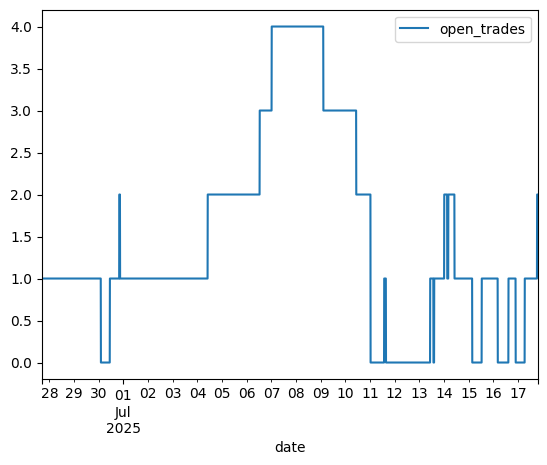

In [14]:
from freqtrade.data.btanalysis import analyze_trade_parallelism


# Analyze the above
parallel_trades = analyze_trade_parallelism(trades, "5m")

parallel_trades.plot()

## Plot results

Freqtrade offers interactive plotting capabilities based on plotly.

In [18]:
from freqtrade.plot.plotting import generate_candlestick_graph


# Limit graph period to keep plotly quick and reactive

# Set pair to PENGU/USDT
pair = "ALGO/USDT"

# Filter trades to one pair
trades_red = trades.loc[trades["pair"] == pair]

# Use candles data instead of undefined 'data' variable
data_red = candles
# Generate candlestick graph
graph = generate_candlestick_graph(
    pair=pair,
    data=data_red,
    trades=trades_red,
    indicators1=["sma20", "ema50", "ema55"],
    indicators2=["rsi", "macd", "macdsignal", "macdhist"],
)

2025-07-20 11:01:45,461 - freqtrade.plot.plotting - INFO - Indicator "sma20" ignored. Reason: This indicator is not found in your strategy.

2025-07-20 11:01:45,462 - freqtrade.plot.plotting - INFO - Indicator "ema50" ignored. Reason: This indicator is not found in your strategy.

2025-07-20 11:01:45,463 - freqtrade.plot.plotting - INFO - Indicator "ema55" ignored. Reason: This indicator is not found in your strategy.

2025-07-20 11:01:45,477 - freqtrade.plot.plotting - INFO - Indicator "rsi" ignored. Reason: This indicator is not found in your strategy.

2025-07-20 11:01:45,478 - freqtrade.plot.plotting - INFO - Indicator "macd" ignored. Reason: This indicator is not found in your strategy.

2025-07-20 11:01:45,479 - freqtrade.plot.plotting - INFO - Indicator "macdsignal" ignored. Reason: This indicator is not found in your strategy.

2025-07-20 11:01:45,480 - freqtrade.plot.plotting - INFO - Indicator "macdhist" ignored. Reason: This indicator is not found in your strategy.

In [19]:
# Show graph inline
# graph.show()

# Render graph in a separate window
graph.show(renderer="browser")

## Plot average profit per trade as distribution graph

## Run a Backtest

Now let's run a backtest to see how the strategy performs on historical data.


In [20]:
# Display backtest results
trades_df = backtest_results['results']
print(f"Total trades: {len(trades_df)}")

if len(trades_df) > 0:
    print(f"Winning trades: {len(trades_df[trades_df['profit_ratio'] > 0])}")
    print(f"Losing trades: {len(trades_df[trades_df['profit_ratio'] <= 0])}")
    print(f"Win rate: {len(trades_df[trades_df['profit_ratio'] > 0]) / len(trades_df) * 100:.2f}%")
    print(f"Average profit per trade: {trades_df['profit_ratio'].mean() * 100:.2f}%")
    print(f"Total profit: {trades_df['profit_ratio'].sum() * 100:.2f}%")
    print(f"Best trade: {trades_df['profit_ratio'].max() * 100:.2f}%")
    print(f"Worst trade: {trades_df['profit_ratio'].min() * 100:.2f}%")

    # Display first few trades
    print("\nFirst 10 trades:")
    display_cols = ['pair', 'open_date', 'close_date', 'profit_ratio', 'exit_reason']
    trades_df[display_cols].head(10)
else:
    print("No trades were executed during the backtest period")


NameError: name 'backtest_results' is not defined

In [ ]:
from freqtrade.optimize.optimize_reports import generate_backtest_stats
import pandas as pd

# Generate detailed backtest statistics
if len(trades_df) > 0:
    # Calculate additional metrics
    starting_balance = config_backtest['stake_amount'] * config_backtest['max_open_trades']

    # Calculate cumulative returns
    trades_df['cumulative_profit'] = trades_df['profit_abs'].cumsum()
    trades_df['cumulative_profit_ratio'] = trades_df['profit_ratio'].cumsum()

    # Calculate drawdown
    peak = trades_df['cumulative_profit'].cummax()
    drawdown = (trades_df['cumulative_profit'] - peak)
    max_drawdown = drawdown.min()

    # Calculate Sharpe ratio (simplified)
    returns = trades_df['profit_ratio']
    sharpe_ratio = returns.mean() / returns.std() if returns.std() > 0 else 0

    print("=== BACKTEST PERFORMANCE METRICS ===")
    print(f"Starting Balance: {starting_balance:.2f} {config_backtest['stake_currency']}")
    print(f"Final Balance: {starting_balance + trades_df['profit_abs'].sum():.2f} {config_backtest['stake_currency']}")
    print(f"Total Return: {trades_df['profit_abs'].sum():.2f} {config_backtest['stake_currency']}")
    print(f"Total Return %: {trades_df['profit_ratio'].sum() * 100:.2f}%")
    print(f"Maximum Drawdown: {max_drawdown:.2f} {config_backtest['stake_currency']}")
    print(f"Sharpe Ratio: {sharpe_ratio:.3f}")
    print(f"Average Trade Duration: {trades_df['trade_duration'].mean():.0f} minutes")

    # Exit reasons breakdown
    print("\n=== EXIT REASONS ===")
    exit_reasons = trades_df['exit_reason'].value_counts()
    for reason, count in exit_reasons.items():
        print(f"{reason}: {count} trades ({count/len(trades_df)*100:.1f}%)")

else:
    print("No trades to analyze - check your strategy parameters or data range")


In [ ]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

if len(trades_df) > 0:
    # 1. Cumulative Returns Chart
    fig_returns = go.Figure()
    fig_returns.add_trace(go.Scatter(
        x=trades_df['close_date'],
        y=trades_df['cumulative_profit'],
        mode='lines',
        name='Cumulative Profit',
        line=dict(color='green', width=2)
    ))
    fig_returns.update_layout(
        title=f'Cumulative Profit Over Time - {pair}',
        xaxis_title='Date',
        yaxis_title=f'Cumulative Profit ({config_backtest["stake_currency"]})',
        hovermode='x unified'
    )
    fig_returns.show()

    # 2. Trade Distribution
    fig_dist = px.histogram(
        trades_df,
        x='profit_ratio',
        nbins=20,
        title='Trade Profit Distribution',
        labels={'profit_ratio': 'Profit Ratio', 'count': 'Number of Trades'}
    )
    fig_dist.add_vline(x=0, line_dash="dash", line_color="red", annotation_text="Break-even")
    fig_dist.show()

    # 3. Monthly Performance (if we have enough data)
    if len(trades_df) > 10:
        trades_df['month'] = pd.to_datetime(trades_df['close_date']).dt.to_period('M')
        monthly_profit = trades_df.groupby('month')['profit_abs'].sum().reset_index()
        monthly_profit['month'] = monthly_profit['month'].astype(str)

        fig_monthly = px.bar(
            monthly_profit,
            x='month',
            y='profit_abs',
            title='Monthly Profit',
            labels={'profit_abs': f'Monthly Profit ({config_backtest["stake_currency"]})', 'month': 'Month'}
        )
        fig_monthly.show()

    # 4. Drawdown Chart
    fig_dd = go.Figure()
    fig_dd.add_trace(go.Scatter(
        x=trades_df['close_date'],
        y=drawdown,
        mode='lines',
        name='Drawdown',
        fill='tonexty',
        line=dict(color='red', width=1)
    ))
    fig_dd.update_layout(
        title='Drawdown Over Time',
        xaxis_title='Date',
        yaxis_title=f'Drawdown ({config_backtest["stake_currency"]})',
        hovermode='x unified'
    )
    fig_dd.show()

else:
    print("No trades to visualize")


In [ ]:
# Multi-pair backtest (optional - uncomment to run)
"""
# Define multiple pairs to test
multi_pairs = ["XMR/USDT", "ETH/USDT", "BTC/USDT", "LTC/USDT"]

# Load data for multiple pairs
multi_data = {}
for test_pair in multi_pairs:
    try:
        pair_data = load_pair_history(
            datadir=data_location,
            timeframe=config["timeframe"],
            pair=test_pair,
            data_format="feather",
        )
        if not pair_data.empty:
            multi_data[test_pair] = pair_data
            print(f"Loaded {len(pair_data)} candles for {test_pair}")
        else:
            print(f"No data available for {test_pair}")
    except Exception as e:
        print(f"Error loading {test_pair}: {e}")

if multi_data:
    # Run backtest on multiple pairs
    backtesting_multi = Backtesting(config_backtest, exchange)
    backtesting_multi.load_bt_data(multi_data)

    print(f"\nRunning backtest on {len(multi_data)} pairs...")
    multi_results = backtesting_multi.backtest(
        processed=backtesting_multi.strategy.advise_all_indicators(multi_data),
        start_date=None,
        end_date=None,
        max_open_trades=config_backtest['max_open_trades'],
        position_stacking=False,
    )

    multi_trades = multi_results['results']
    print(f"Multi-pair backtest completed with {len(multi_trades)} trades")

    # Performance by pair
    if len(multi_trades) > 0:
        pair_performance = multi_trades.groupby('pair').agg({
            'profit_ratio': ['count', 'mean', 'sum'],
            'trade_duration': 'mean'
        }).round(4)
        pair_performance.columns = ['Trades', 'Avg_Profit_%', 'Total_Profit_%', 'Avg_Duration_min']
        print("\nPerformance by pair:")
        print(pair_performance)
"""

print("Multi-pair backtest code is commented out. Uncomment to run with multiple pairs.")


In [ ]:
import plotly.figure_factory as ff


hist_data = [trades.profit_ratio]
group_labels = ["profit_ratio"]  # name of the dataset

fig = ff.create_distplot(hist_data, group_labels, bin_size=0.01)
fig.show()

Feel free to submit an issue or Pull Request enhancing this document if you would like to share ideas on how to best analyze the data.